In [86]:
%matplotlib inline

import os
import sys
import copy
import warnings

import torch
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

sys.path.append('../../../')

%load_ext autoreload
%autoreload 2

from computer_vision.yolov11_pose.parameter_parser import parser
from computer_vision.yolov11_pose.nn.tasks import PoseModel
from computer_vision.yolov11_pose.utils.metrics import DetMetrics, PoseMetrics, box_iou
from computer_vision.yolov11_pose.utils.checks import check_imgsz
from computer_vision.yolov11_pose.data.utils import check_det_dataset
from computer_vision.yolov11_pose.data.build import build_yolo_dataset, build_dataloader
from computer_vision.yolov11_pose.cfg import get_cfg
from computer_vision.yolov11_pose.utils.torch_utils import unwrap_model
from computer_vision.yolov11_pose.utils.nms import non_max_suppression # for post processing
from computer_vision.yolov11_pose.utils.ops import xywh2xyxy, xyxy2xywh

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
main_dirpath='D:/results/yolov11_pose'
checkpoint_dirpath=os.path.join(main_dirpath, 'predict')
output_dirpath=os.path.join(main_dirpath, 'validation')
args=parser.parse_args(f'--save-dir {output_dirpath} --data ../coco-pose.yaml --visualize'.split())


task='pose'
if task=='pose':
    data_dirpath='D:/data/ultralytics/coco-pose/images/train2017'
    data_config='../coco-pose.yaml'
elif task=='detect':
    data_dirpath='D:/data/ultralytics/coco/images/val2017'
    data_config='../coco.yaml'
elif task=='segment':
    data_dirpath='D:/data/ultralytics/coco8-seg/images/val'
    data_config='../coco8-seg.yaml'



hyp=get_cfg()
dataset=build_yolo_dataset(args=args, cfg=hyp, task=task, img_path=data_dirpath, batch=args.batch_size or hyp.batch, 
                   data=data_config,  mode='train', rect=False, stride=32, channels=3)
for i in range(4): print(dataset.labels[i]['cls'].shape)
dataloader=build_dataloader(dataset, batch=hyp.batch, workers=1, shuffle=True, drop_last=True, pin_memory=True)


In data.build.build_yolo_dataset batch 16
In data.dataset.YOLODataset.get_labels cache_path D:\data\ultralytics\coco-pose\labels\train2017.cache
Scanning D:\data\ultralytics\coco-pose\labels\train2017.cache... 56599 images, 61688 backgrounds, 0 corrupts
In data.dataset.YOLODataset.__init__ augment True rect False
(0, 1)
(0, 1)
(0, 1)
(0, 1)
In data.build.build_dataloader batch 16


In [3]:
cfg='../yolo11-pose.yaml'
model=PoseModel(cfg=cfg,nc=1,verbose=True)
model.fuse(); # we need to call `fuse` so we can successfully load pretrained weight
checkpoint_file=os.path.join(checkpoint_dirpath, 'yolo11n_torch.pt')
assert os.path.isfile(checkpoint_file), f'{checkpoint_file} does not exist'
checkpoint=torch.load(checkpoint_file, weights_only=False)
try:
    model.load_state_dict(checkpoint['model'])
except RuntimeError as err:
    state_dict=copy.deepcopy(model.state_dict())
    for name, params in checkpoint['model'].items():
        name=name[len('model.'):] # each parameter name is model.model.xxx so we need to remove 1 model.
        
        if name not in state_dict or params.shape!=state_dict[name].shape:
            print(name, name in state_dict, (params.shape,state_dict[name].shape) if name in state_dict else None)
        else: state_dict[name]=params
    model.load_state_dict(state_dict)

model.train()

In nn.tasks.PoseModel.__init__ type(cfg) <class 'str'>, cfg ../yolo11-pose.yaml
In nn.tasks.parse_model d {'nc': 1, 'kpt_shape': [17, 3], 'scales': {'n': [0.5, 0.25, 1024], 's': [0.5, 0.5, 1024], 'm': [0.5, 1.0, 512], 'l': [1.0, 1.0, 512], 'x': [1.0, 1.5, 512]}, 'backbone': [[-1, 1, 'Conv', [64, 3, 2]], [-1, 1, 'Conv', [128, 3, 2]], [-1, 2, 'C3k2', [256, False, 0.25]], [-1, 1, 'Conv', [256, 3, 2]], [-1, 2, 'C3k2', [512, False, 0.25]], [-1, 1, 'Conv', [512, 3, 2]], [-1, 2, 'C3k2', [512, True]], [-1, 1, 'Conv', [1024, 3, 2]], [-1, 2, 'C3k2', [1024, True]], [-1, 1, 'SPPF', [1024, 5]], [-1, 2, 'C2PSA', [1024]]], 'head': [[-1, 1, 'nn.Upsample', ['None', 2, 'nearest']], [[-1, 6], 1, 'Concat', [1]], [-1, 2, 'C3k2', [512, False]], [-1, 1, 'nn.Upsample', ['None', 2, 'nearest']], [[-1, 4], 1, 'Concat', [1]], [-1, 2, 'C3k2', [256, False]], [-1, 1, 'Conv', [256, 3, 2]], [[-1, 13], 1, 'Concat', [1]], [-1, 2, 'C3k2', [512, False]], [-1, 1, 'Conv', [512, 3, 2]], [[-1, 10], 1, 'Concat', [1]], [-1, 2, 

PoseModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (m): ModuleList(
        (0): Bottleneck(
          (cv1): Conv(
            (conv): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (act): SiLU(inplace=True)
          )
          (cv2): Conv(
            (conv): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (act): SiLU(inplace=True)
          )
        )
      )
    )
    (3): Conv(
      (conv): Conv2d(64, 64, 

In [4]:
model.args=hyp

batch=next(iter(dataloader))
print({k:(v.shape if isinstance(v, torch.Tensor) else v) for k, v in batch.items()})

{'batch_idx': torch.Size([50]), 'bboxes': torch.Size([50, 4]), 'cls': torch.Size([50, 1]), 'im_file': ['D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000388403.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000087638.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000398753.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000194000.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000297258.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000215398.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000397701.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000528631.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000549347.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000549539.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000444100.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000109825.jpg', 'D:\\data\\ultralytic

0,1,

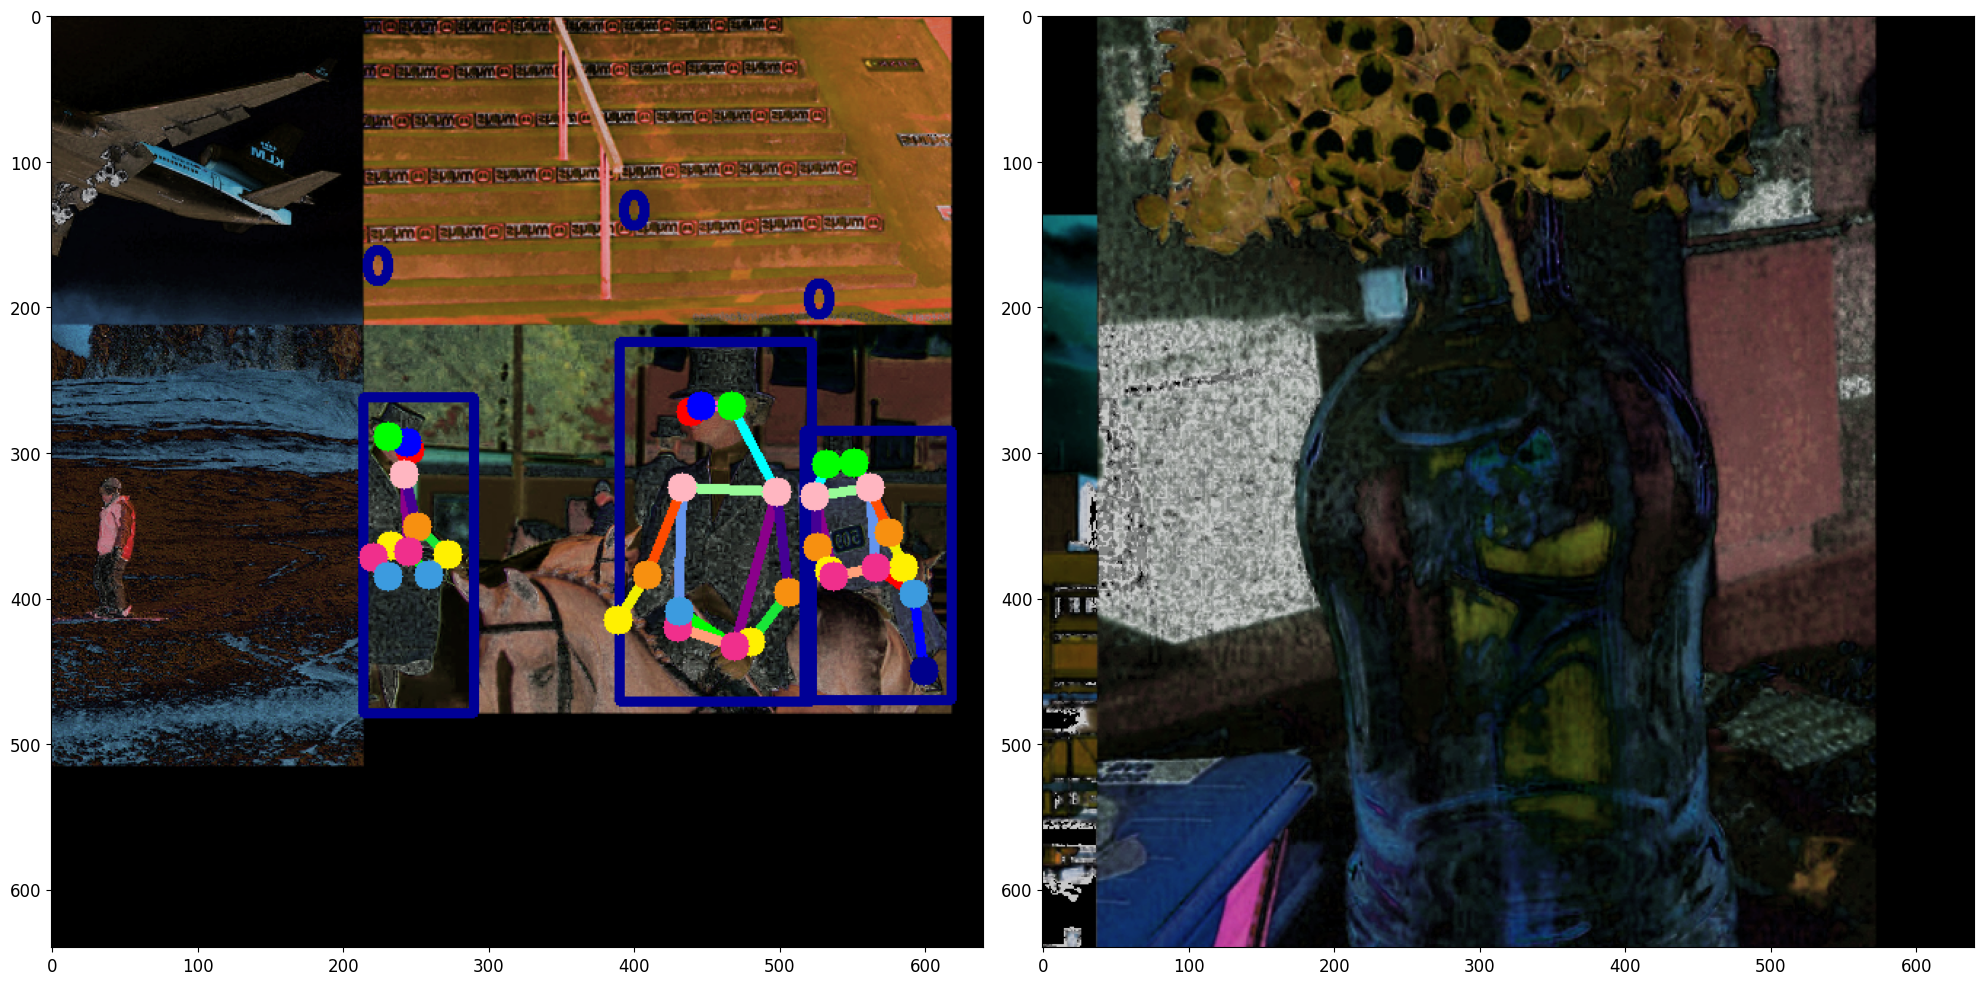

In [5]:
from computer_vision.misc import alpha_bending, instance2mask

from matplotlib import patches
import matplotlib.pyplot as plt
from computer_vision.yolov11_pose.utils.ops import xywh2xyxy
from computer_vision.yolov11_pose.utils.viz import general_skeleton_overlay

cmap = plt.get_cmap('tab10', 10)
plt.rcParams.update({'font.size'   : 12})

n_data=2
ncols=2
nrows=int(np.ceil(n_data/ncols))

_, ax=plt.subplots(nrows,ncols,figsize=(20,20))
for idx, item in enumerate(dataloader):
    if idx==n_data: break
    print(idx, end=',')
    batch_idx=item['batch_idx']
    flag=batch_idx==idx

    classes=item['cls'][flag].flatten() # (N,1) to (N,)
    classes=[f'{int(c)}' for c in classes]
    img=item['img'][idx] # (C,H,W)
    height, width=img.shape[-2:]
    if isinstance(img, torch.Tensor):
        img=img.permute(1,2,0).contiguous().numpy() # HxWxC
        img=img[...,::-1] # RGB to BGR

    bboxes=item['bboxes'][flag].clone()
    bboxes=xywh2xyxy(bboxes)
    # denormalize bboxes
    bboxes[...,[0,2]]*=width
    bboxes[...,[1,3]]*=height
    bboxes=bboxes.numpy()
    
    keypoints=item['keypoints'][flag].clone() if 'keypoints' in item else None # NxMx3
    if keypoints is not None: # denormalized
        keypoints[...,0]*=width
        keypoints[...,1]*=height
        keypoints=keypoints.numpy()
    if keypoints is not None:
        img=general_skeleton_overlay(img_bgr=img, class_names=classes, bboxes=bboxes, keypoints=keypoints)
        ax[idx].imshow(img[...,::-1])
    else: ax[idx].imshow(img[...,::-1])
    if keypoints is None:
        for j, (box,cls) in enumerate(zip(bboxes, classes)):
            # Create a Rectangle patch
            rect = patches.Rectangle(box[:2], box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor=cmap(j), facecolor='none')
            # Add the patch to the Axes
            ax[idx].add_patch(rect)
            ax[idx].text(*box[:2], f'{cls}', color=cmap(j), fontsize=12)

plt.tight_layout()


In [6]:
from computer_vision.yolov11_pose.utils.tal import make_anchors

In [7]:
batch=copy.deepcopy(item)
print({k:(v.shape if isinstance(v, torch.Tensor) else v) for k, v in batch.items()})

# preprocess batch
batch["img"] = batch["img"].float() / 255

# since batch is dict model.forward internally calls loss function
# the loss function checks whether criterion was defined;if not, defined it
# then call forward model on image and call criterion on preds and batch

# here is from loss function in model class
preds=None
if getattr(model, "criterion", None) is None: model.criterion=model.init_criterion()
if preds is None: preds=model(batch['img'])
# model.criterion(preds, batch) which in turn, calls loss.loss(.)

{'batch_idx': torch.Size([16]), 'bboxes': torch.Size([16, 4]), 'cls': torch.Size([16, 1]), 'im_file': ['D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000025123.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000074035.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000438026.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000260025.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000501260.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000294918.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000556505.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000550239.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000118109.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000110034.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000168716.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000487295.jpg', 'D:\\data\\ultralytic

In [8]:
print('preds ', type(preds), len(preds))
print('preds[0] ', type(preds[0]), len(preds[0]), [x.shape for x in preds[0]])
print('preds[1] ', type(preds[1]), preds[1].shape)

preds  <class 'tuple'> 2
preds[0]  <class 'list'> 3 [torch.Size([16, 65, 80, 80]), torch.Size([16, 65, 40, 40]), torch.Size([16, 65, 20, 20])]
preds[1]  <class 'torch.Tensor'> torch.Size([16, 51, 8400])


In [9]:
80**2+40**2+20**2

8400

In [21]:
# model.criterion(preds, batch) which in turn, calls loss.__call__(preds, batch)
# def __call__(self, preds:Any, batch:dict[str, torch.Tensor])->tuple[torch.Tensor, torch.Tensor]
"""Calculate the total loss and detach it for pose estimation
Args:
    preds (tuple[list[torch.Tensor], torch.Tensor]): (1) List of BxOxHxW features from each level where O is the output dimension
        as the sum of 4*reg_max (typically 16) and number of classes, and HxW differs according to levels; and (2) BxPxN tensor of 
        predicted keypoints where P is the number of keypoints multiplied by its dimension (e.g., 17x3=51) and N is sum of all H*W
        from all levels, e.g, if preds[0] is [BxOx80x80, BxOx40x40, BxOx20x20] then N=80**2+40**2+20**2
    
    
"""
loss=torch.zeros(5, device=model.criterion.device) # box, pose, kobj, cls, dfl
# Each feats is of size BxOxHxW where O is the output dimension, and HxW is differed depending on output levels
#    Here O is the sum of 4*reg_max (typically 16) and nc (typically 1) so it is typically 65
#    feats is ordered from high-resolution to lower resolutions
# pred_kpts is of size BxPxN where P is the number of keypoints multiplied by its dimension (e.g., 51=17x3) and 
#     N is H*W
feats, pred_kpts=preds if isinstance(preds[0], list) else preds[1]
print('feats ', type(feats), len(feats))
print('pred_kpts ', type(pred_kpts), pred_kpts.shape)
# cat converts BxOxHxW where H, W differ per level to BxOxN where N is the sum of H*W from all levels
# split gives BxRxN and BxLxN where R is 4*reg_max and L is nc
pred_distri, pred_scores=torch.cat([xi.view(feats[0].shape[0], model.criterion.no, -1) for xi in feats], 2).split(
    (model.criterion.reg_max*4, model.criterion.nc), 1
)
print(f'pred_distri {pred_distri.shape}, pred_scores {pred_scores.shape}')

# B, grids, ...
pred_scores=pred_scores.permute(0,2,1).contiguous() # from BxLxN to BxNxL
pred_distri=pred_distri.permute(0,2,1).contiguous() # from BxRxN to BxNxR
pred_kpts=pred_kpts.permute(0,2,1).contiguous() # from BxPxN to BxNxP where P is the number of keypoints multiplied by its dimension

print(f'pred_distri {pred_distri.shape}, pred_scores {pred_scores.shape}, pred_kpts {pred_kpts.shape}')

dtype=pred_scores.dtype
# feats[0] is corresponding to stride[0] i.e., highest feat resolution with lowest stride
imgsz=torch.tensor(feats[0].shape[2:], device=model.criterion.device, dtype=dtype)*model.criterion.stride[0] # image size (h, w)
anchor_points, stride_tensor=make_anchors(feats, model.criterion.stride, 0.5) # Nx2 and Nx1

feats  <class 'list'> 3
pred_kpts  <class 'torch.Tensor'> torch.Size([16, 51, 8400])
pred_distri torch.Size([16, 64, 8400]), pred_scores torch.Size([16, 1, 8400])


In [79]:
# Targets
batch_size=pred_scores.shape[0]
batch_idx=batch['batch_idx'].view(-1,1) # from shape of (L,) to (L,1) 
targets=torch.cat([batch_idx, batch['cls'], batch['bboxes']], 1) # combine (L,1), (L,1), (L,4) to (L,6)
print('targets ', targets.shape)
# BxMx5 where M is the maximum labels each image has, 5 for cls and xyxy bounding box coordinates in pixel units
targets=model.criterion.preprocess(targets, batch_size, scale_tensor=imgsz[[1,0,1,0]]) 
gt_labels, gt_bboxes=targets.split((1,4), 2) # BxMx1 cls, BxMx4 xyxy
# check whether sum of box coordinates > 0.. This mask is float32 with value of 1 for a box having the sum of xyxy >0
mask_gt=gt_bboxes.sum(2, keepdim=True).gt_(0.) 

# Predicted boxes
pred_bboxes=model.criterion.bbox_decode(anchor_points, pred_distri) # xyxy, (b, N, 4) where N is the number of anchors or sum of H*W from all levels
# keypoints are predicted relative to the cell/anchor center as normalized offsets 
pred_kpts=model.criterion.kpts_decode(anchor_points, pred_kpts.view(batch_size, -1, *model.criterion.kpt_shape)) # (b, N, 17, 3)
# _, target_bboxes, target_scores, fg_mask, target_gt_idx=model.criterion.assigner(pred_scores.detach().sigmoid(),
# (pred_bboxes.detach()*stride_tensor).type(gt_bboxes.dtype), anchor_points*stride_tensor, gt_labels, gt_bboxes, mask_gt)

targets  torch.Size([16, 6])


In [104]:
assigner=model.criterion.assigner
pd_scores_=pred_scores.detach().sigmoid() 
pd_bboxes_=(pred_bboxes.detach()*stride_tensor).type(gt_bboxes.dtype)
anc_points=anchor_points*stride_tensor

# @torch.no_grad()
# def forward(self, pd_scores, pd_bboxes, anc_points, gt_labels, gt_bboxes, mask_gt):
"""Compute the task-aligned assignment
Args:
    pd_scores (torch.Tensor): Predicted classification scores with shape (B,N,C) where N is the number of anchors/sum of H*W from all levels
        C is the number of classes
    pd_bboxes (torch.Tensor): Predicted bounding boxes with shape (B, N, 4) in the xyxy format and pixel units
    anc_points (torch.Tensor): Anchor points with shape (N, 2) where 2 is for x and y and in pixel units
    gt_labels (torch.Tensor): Ground truth labels with shape (B, n_max_boxes, 1) where n_max_boxes is the maximum number of boxes for 
        each image in this batch
    gt_bboxes (torch.Tensor): Ground truth boxes with shape (B, n_max_boxes, 4) in the xyxy format in pixel units
    mask_gt (torch.Tensor): Mask for valid ground truth boxes with shape (B, n_max_boxes, 1)
Returns:
    target_labels (torch.Tensor): Target labels with shape (B, N) where N is the number of anchors/sum of H*W from all levels
    target_bboxes (torch.Tensor): Target bounding boxes with shape (B, N, 4)
    target_scores (torch.Tensor): Target scores with shape (B, N, C) where C is the number of classes
    fg_mask (torch.Tensor): Foreground mask with shape (B, N)
    target_gt_idx (torch.Tensor): Target ground truth indices with shape (B, N)
References:
    https://github.com/Nioolek/PPYOLOE_pytorch/blob/master/ppyoloe/assigner/tal_assigner.py
"""
assigner.bs=pd_scores_.shape[0]
assigner.n_max_boxes=gt_bboxes.shape[1]
device=gt_bboxes.device
# if assigner.n_max_boxes==0:
#     return (
#         torch.full_like(pd_scores_[...,0], assigner.num_classes), # (B,N)
#         torch.zeros_like(pd_bboxes_), # (B,N,4)
#         torch.zeros_like(pd_scores_), # (B,N,C)
#         torch.zeros_like(pd_scores_[...,0]), # (B,N)
#         torch.zeros_like(pd_scores_[...,0]), # (B,N)
#     )
# try: return assigner._forward(pd_scores_, pd_bboxes_, anc_points, gt_labels, gt_bboxes, mask_gt)
# except torch.cuda.OutOfMemoryError:
#     # Move tensors to CPU, compute, then move back to original device
#     warnings.warn("CUDA OutOfMemoryError in TaskAlignedAssigner, using CPU")
#     cpu_tensors=[t.cpu() for t in (pd_scores_, pd_bboxes_, anc_points, gt_labels, gt_bboxes, mask_gt)]
#     result=assigner._forward(*cpu_tensors)
#     return tuple(t.to(device) for t in result)

In [85]:
# def _forward(self, pd_scores, pd_bboxes, anc_points, gt_labels, gt_bboxes, mask_gt):

# mask_pos, align_metric, overlaps=assigner.get_pos_mask(pd_scores, pd_bboxes, gt_labels, gt_bboxes, anc_points, mask_gt)


torch.Size([16, 8400, 1])

In [102]:
# def get_pos_mask(self, pd_scores, pd_bboxes, gt_labels, gt_bboxes, anc_points, mask_gt):
"""Get positive mask for each ground truth box
Args:
    pd_scores (torch.Tensor): Predicted classification scores with shape (B, N, C) where N is the number of anchors/sum of all H*W from all levels
        and C is the number of classes
    pd_bboxes (torch.Tensor): Predicted bounding boxes with shape (B, N, 4) in the xyxy format in pixel units
    gt_labels (torch.Tensor): Ground truth labels with shape (B, n_max_boxes, 1) where n_max_boxes is the maximum number of boxes for each image
        in this batch
    gt_bboxes (torch.Tensor): Ground truth boxes with shape (B, n_max_boxes, 4) in the xyxy format in pixel units
    anc_points (torch.Tensor): Anchor points with shape (N, 2) where 2 is for x, y in pixel units
    mask_gt (torch.Tensor): Mask for valid ground truth boxes with shape (B, n_max_boxes, 1)
Returns:
    mask_pos (torch.Tensor): Positive mask with shape (B, n_max_boxes, 
"""
mask_in_gts=assigner.select_candidates_in_gts(anc_points, gt_bboxes) # (B,n_max_boxes, N) mask of positive anchors of type float32
# Get anchor_align metric, (B, n_max_boxes, N)

In [130]:
mask_gt_=mask_gt*mask_in_gts
# def get_box_metrics(self, pd_scores, pd_bboxes, gt_labels, gt_bboxes, mask_gt):
"""Compute alignment metric given predicted and ground truth bounding boxes.
Args:
    pd_score (torch.Tensor): Predicted classification scores with shape (B, N, C) where N is the number of anchors/sum of H*W from all 
        feature levels and C is the number of classes
    pd_bboxes (torch.Tensor): Predicted bounding boxes with shape (B, N, 4) in the xyxy format in pixel unit
    gt_labels (torch.Tensor): Ground truth labels with shape (B, n_max_boxes, 1) where n_max_boxes is the maximum number of boxes for
        each image in this batch
    gt_bboxes (torch.Tensor): Ground truth boxes with shape (B, n_max_boxes, 4) in the xyxy format in pixel unit
    mask_gt (torch.Tensor): Mask for valid ground truth boxes with positive anchors with shape (B, n_max_boxes, N)
Returns:
    align_metric (torch.Tensor): Alignment metric combining classification and localization
    overlaps (torch.Tensor): IoU overlaps between predicted and ground truth boxes
"""
na=pd_bboxes_.shape[-2] # number of anchors
mask_gt_=mask_gt_.bool() # (B, n_max_boxes, N)
overlaps=torch.zeros([assigner.bs, assigner.n_max_boxes, na], dtype=pd_bboxes_.dtype, device=pd_bboxes_.device)  # (B, n_max_boxes, N)
bbox_scores=torch.zeros([assigner.bs, assigner.n_max_boxes, na], dtype=pd_scores_.dtype, device=pd_scores_.device) # (B, n_max_boxes, N)

ind=torch.zeros([2,assigner.bs, assigner.n_max_boxes], dtype=torch.long) # (2,B,n_max_boxes)
# Batch indices
ind[0]=torch.arange(end=assigner.bs).view(-1,1).expand(-1,assigner.n_max_boxes) # from (B,) to (B,1) to (B,n_max_boxes)
# Class indices for each ground truth object
ind[1]=gt_labels.squeeze(-1) # (B,n_max_boxes)
# Get the scores of each grid for each gt cls 
# pred_scores[ind[0]] returns tensor of size (B, n_max_boxes, N, 1)
# pred_scores[...,ind[1]] returns tensor of size (B, N, B, n_max_boxes)
# pred_scores[ind[0],:,ind[1]] returns tensor of size (B, n_max_boxes, N)
# What does pred_scores[ind[0],:,ind[1]] do? For each (i,j) index to (B,n_max_boxes) of ind[0] and ind[1], Pytorch pairs them together
# i.e., (ind[0]ij,:,ind[1]ij). Also, in advance indexing, if non-adjacenet dimensions are indexed (like dim0, and dim2 with dim1 left as a
# a slice), the indexed dimensions are pushed to the front by default. Thus, the indexing of dim0 and dim2 creates a base shape of 
# (B,n_max_boxes) followed by the sliced dimension of size N
# pred_scores[ind[0],:,ind[1]] mean for each batch ind[0], give me scores for ground truth box ind[1]'s class
bbox_scores[mask_gt_]=pd_scores_[ind[0],:,ind[1]][mask_gt_]  # (B, n_max_boxes, N)

# (B,N,4)->(B,1,N,4)->(B,n_max_boxes,N,4) and mask_gt filtering yields [P,4] where P is the number of boxes that are valid across batches,
# anchors, and ground-truth boxes
pd_boxes=pd_bboxes_.unsqueeze(1).expand(-1, assigner.n_max_boxes,-1,-1)[mask_gt_] 
# (B,n_max_boxes,4)->(B,n_max_boxes, 1,4)->(B,n_max_boxes,N,4) and mask_gt filtering yields [P,4] 
gt_boxes=gt_bboxes.unsqueeze(2).expand(-1,-1,na,-1)[mask_gt_]
# overlaps[mask_gt_]=assigner.iou_calculation(gt_boxes, pd_boxes)

torch.Size([6339, 4])

torch.Size([6339, 4])

(0.4052847345693511, 0.4052847345693511, 1.6211389382774046)